Importing the Dependencies

In [51]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier

Data Collection and Processing

In [52]:
# loading the csv data to a Pandas DataFrame
heart_data = pd.read_csv('../data/heart_disease_data.csv')

In [53]:
# print first 5 rows of the dataset
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [54]:
# print last 5 rows of the dataset
heart_data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [55]:
# number of rows and columns in the dataset
heart_data.shape

(303, 14)

In [56]:
# getting some info about the data
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [57]:
# checking for missing values
heart_data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [58]:
# statistical measures about the data
heart_data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [59]:
# checking the distribution of Target Variable
heart_data['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

1 --> Defective Heart

0 --> Healthy Heart

## Data Visualization

### 1. Target Distribution

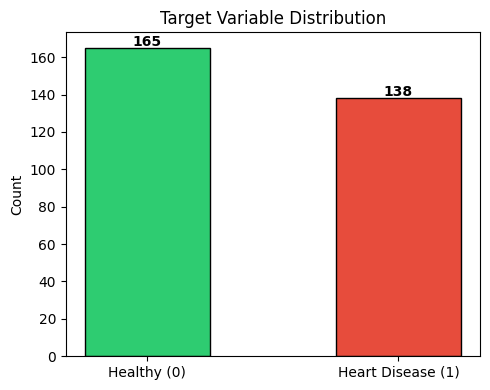

In [60]:
target_counts = heart_data['target'].value_counts()
plt.figure(figsize=(5, 4))
plt.bar(['Healthy (0)', 'Heart Disease (1)'], target_counts.values,
        color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
for i, v in enumerate(target_counts.values):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.title('Target Variable Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 2. Age Distribution by Target

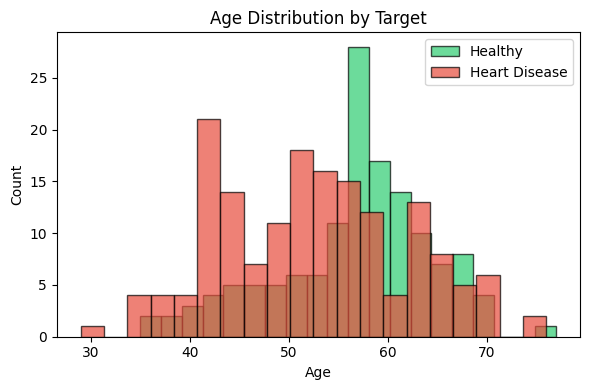

In [61]:
plt.figure(figsize=(6, 4))
plt.hist(heart_data[heart_data['target']==0]['age'], bins=20,
         alpha=0.7, color='#2ecc71', label='Healthy', edgecolor='black')
plt.hist(heart_data[heart_data['target']==1]['age'], bins=20,
         alpha=0.7, color='#e74c3c', label='Heart Disease', edgecolor='black')
plt.title('Age Distribution by Target')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

### 3. Sex vs Heart Disease

<Figure size 500x400 with 0 Axes>

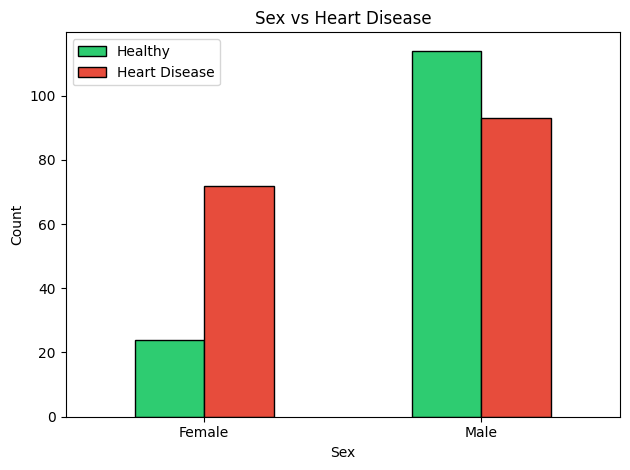

In [62]:
plt.figure(figsize=(5, 4))
sex_target = heart_data.groupby(['sex', 'target']).size().unstack()
sex_target.plot(kind='bar', color=['#2ecc71', '#e74c3c'],
                edgecolor='black', width=0.5)
plt.title('Sex vs Heart Disease')
plt.xlabel('Sex')
plt.xticks([0, 1], ['Female', 'Male'], rotation=0)
plt.ylabel('Count')
plt.legend(['Healthy', 'Heart Disease'])
plt.tight_layout()
plt.show()

### 4. Chest Pain Type vs Heart Disease

<Figure size 600x400 with 0 Axes>

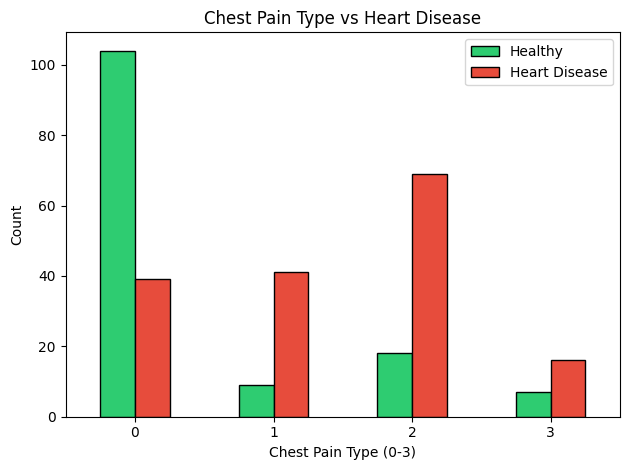

In [63]:
plt.figure(figsize=(6, 4))
cp_target = heart_data.groupby(['cp', 'target']).size().unstack()
cp_target.plot(kind='bar', color=['#2ecc71', '#e74c3c'],
               edgecolor='black', width=0.5)
plt.title('Chest Pain Type vs Heart Disease')
plt.xlabel('Chest Pain Type (0-3)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Healthy', 'Heart Disease'])
plt.tight_layout()
plt.show()

### 5. Max Heart Rate by Target

/tmp/ipykernel_81173/4186936810.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Healthy', 'Heart Disease'],


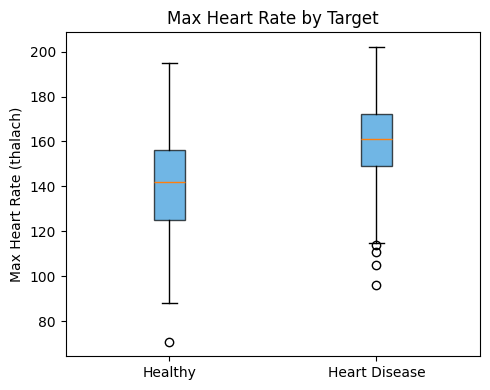

In [64]:
plt.figure(figsize=(5, 4))
data_to_plot = [heart_data[heart_data['target']==0]['thalach'],
                heart_data[heart_data['target']==1]['thalach']]
plt.boxplot(data_to_plot, labels=['Healthy', 'Heart Disease'],
            patch_artist=True,
            boxprops=dict(facecolor='#3498db', alpha=0.7))
plt.title('Max Heart Rate by Target')
plt.ylabel('Max Heart Rate (thalach)')
plt.tight_layout()
plt.show()

### 6. Feature Correlation Heatmap

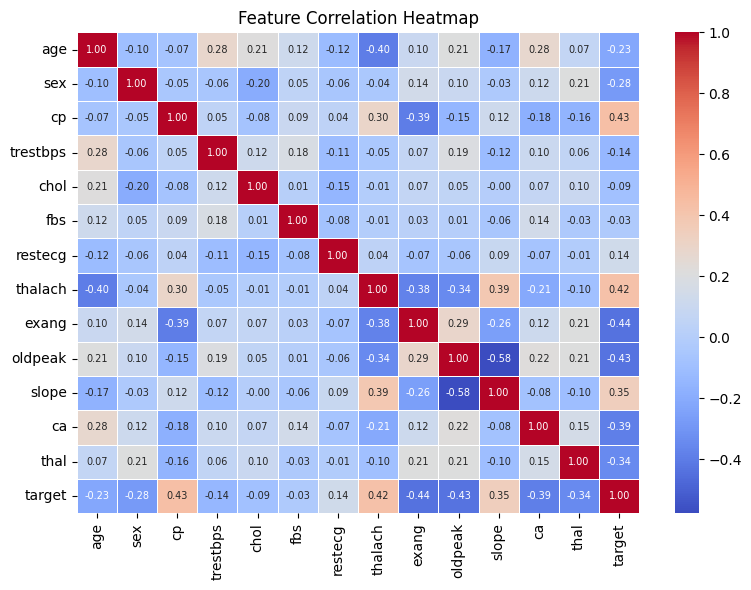

In [65]:
plt.figure(figsize=(8, 6))
corr = heart_data.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

Splitting the Features and Target

In [66]:
X = heart_data.drop(columns='target', axis=1)
Y = heart_data['target']

In [67]:
print(X)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1      115      1      1.2   
302   57    0   1       130   236    0        0      174      0      0.0   

     slope  ca  thal  
0        0   0     1  
1        0   0     2  
2        2   0    

In [68]:
print(Y)

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64


Splitting the Data into Training data & Test Data

In [69]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

Feature Encoding & Scaling

In [70]:
# Encoding categorical features and scaling numerical features
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify categorical and numerical columns
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

# Create a column transformer with encoding and scaling
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# Fit the preprocessor on training data and transform both train and test
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [71]:
print(X.shape, X_train.shape, X_test.shape)

(303, 13) (242, 29) (61, 29)


Model Training

Random Forest Classifier

In [72]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=4, 
    min_samples_leaf=5, 
    random_state=42
)


In [73]:
# training the RandomForestClassifier model with Training data
model.fit(X_train, Y_train)
# Predict on test data
X_test_prediction = model.predict(X_test)

Confusion Matrix

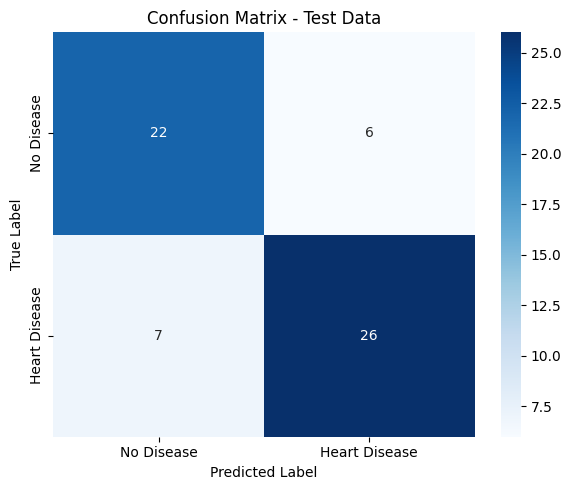


Classification Report:

               precision    recall  f1-score   support

   No Disease       0.76      0.79      0.77        28
Heart Disease       0.81      0.79      0.80        33

     accuracy                           0.79        61
    macro avg       0.79      0.79      0.79        61
 weighted avg       0.79      0.79      0.79        61



In [74]:
# Confusion Matrix on Test Data
cm = confusion_matrix(Y_test, X_test_prediction)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Test Data')
plt.tight_layout()
plt.show()

print('\nClassification Report:\n')
print(classification_report(Y_test, X_test_prediction, target_names=['No Disease', 'Heart Disease']))

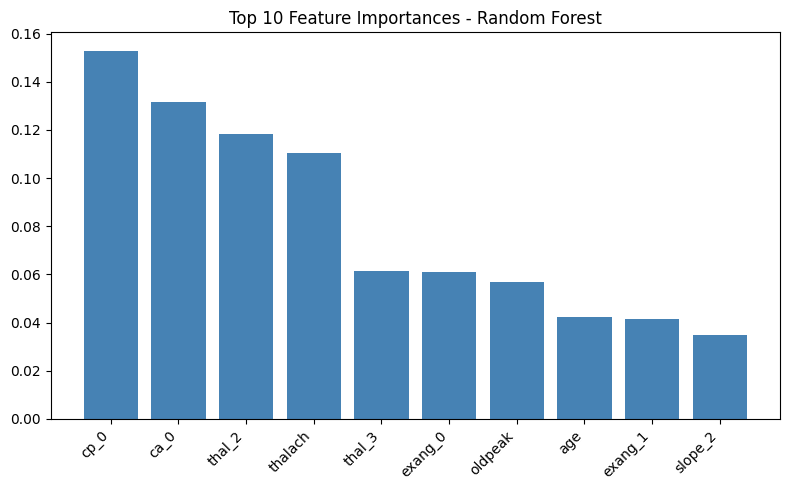

In [75]:
# Feature Importance
feature_names = (numerical_cols +
    preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist())
importances = model.feature_importances_
indices = np.argsort(importances)[::-1][:10]
plt.figure(figsize=(8, 5))
plt.bar(range(10), importances[indices], color='steelblue')
plt.xticks(range(10), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.title('Top 10 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

Building a Predictive System

In [76]:
input_data = (63,1,3,145,233,1,0,150,0,2.3,0,0,1)

# Column names must match training data
columns = X.columns.tolist()

# Convert to DataFrame to apply preprocessor
input_df = pd.DataFrame([input_data], columns=columns)

# Apply the same preprocessor used during training
input_transformed = preprocessor.transform(input_df)

prediction = model.predict(input_transformed)
print(prediction)

if (prediction[0] == 0):
    print('The Person does not have a Heart Disease')
else:
    print('The Person has Heart Disease')


[1]
The Person has Heart Disease
